In [6]:
# ============================================
# CELL 1: LOAD DATA + STRIP COLUMN NAMES
# ============================================

import pandas as pd
import numpy as np

df = pd.read_csv("Heart_Prediction.csv")

print("Initial shape:", df.shape)

# Strip spaces from column names (good practice)
df.columns = df.columns.str.strip()

print("\nColumn names after strip:")
print(df.columns.tolist())

df.head()


Initial shape: (1016, 12)

Column names after strip:
['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease']


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,66,M,NAP,116,100,0,ST,122,N,0.6,Up,0
1,41,M,ATA,117,239,0,ST,148,N,2.0,Up,0
2,32,M,ASY,118,100,1,Normal,135,Y,1.2,Flat,1
3,51,F,ATA,115,400,0,Normal,140,N,0.0,Up,0
4,56,M,NAP,152,123,1,Normal,174,N,0.2,Up,0


In [7]:
# ============================================
# CELL 2: STRIP SPACES IN STRING/CATEGORICAL VALUES
# ============================================

# Find object (string) columns
obj_cols = df.select_dtypes(include="object").columns.tolist()
print("Object columns:", obj_cols)

# Strip leading/trailing spaces inside text columns
for col in obj_cols:
    df[col] = df[col].astype(str).str.strip()

print("\nSample unique values after stripping (first few):")
for col in obj_cols:
    print(col, "->", df[col].unique()[:5])


Object columns: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

Sample unique values after stripping (first few):
Sex -> ['M' 'F']
ChestPainType -> ['NAP' 'ATA' 'ASY' 'TA']
RestingECG -> ['ST' 'Normal' 'LVH']
ExerciseAngina -> ['N' 'Y']
ST_Slope -> ['Up' 'Flat' 'Down']


In [8]:
# ============================================
# CELL 3: CHECK NULL / MISSING VALUES
# ============================================

missing_per_col = df.isnull().sum().sort_values(ascending=False)
total_missing = missing_per_col.sum()

print("Missing values per column:\n", missing_per_col)
print("\nTotal missing values:", total_missing)


Missing values per column:
 Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Total missing values: 0


In [9]:
# ============================================
# CELL 4: HANDLE MISSING VALUES (IF ANY)
# Strategy:
# - Numeric -> median
# - Categorical -> mode
# ============================================

shape_before = df.shape
total_missing_before = df.isnull().sum().sum()

if total_missing_before > 0:
    # Numeric columns: fill with median
    num_cols = df.select_dtypes(include=["int64", "float64"]).columns
    for col in num_cols:
        if df[col].isnull().any():
            df[col] = df[col].fillna(df[col].median())

    # Categorical columns: fill with mode
    for col in obj_cols:
        if df[col].isnull().any():
            df[col] = df[col].fillna(df[col].mode()[0])

total_missing_after = df.isnull().sum().sum()

print("Shape before missing handling:", shape_before)
print("Shape after missing handling :", df.shape)
print("Total missing BEFORE:", total_missing_before)
print("Total missing AFTER :", total_missing_after)


Shape before missing handling: (1016, 12)
Shape after missing handling : (1016, 12)
Total missing BEFORE: 0
Total missing AFTER : 0


In [10]:
# ============================================
# CELL 5: DUPLICATE CHECK + REMOVE
# ============================================

dup_count = df.duplicated().sum()
print("Duplicate rows found:", dup_count)

shape_before = df.shape
df = df.drop_duplicates()
shape_after = df.shape

print("Shape before removing duplicates:", shape_before)
print("Shape after removing duplicates :", shape_after)


Duplicate rows found: 0
Shape before removing duplicates: (1016, 12)
Shape after removing duplicates : (1016, 12)


In [12]:
# ============================================
#  BASIC EDA
# ============================================

# Dataset shape
print("Dataset shape:", df.shape)

# Check missing values
print("\nTotal missing values:", df.isnull().sum().sum())

# Numerical summary
print("\nNumerical feature summary:")
display(df.describe().T)

# Target distribution
print("\nTarget (HeartDisease) distribution:")
print(df["HeartDisease"].value_counts())

print("\nTarget proportion:")
print(df["HeartDisease"].value_counts(normalize=True))


Dataset shape: (1016, 12)

Total missing values: 0

Numerical feature summary:


,count,mean,std,min,25%,50%,75%,max
Age,1016.0,52.335630,9.842431,23.0,46.0,53.00,59.0,80.0
RestingBP,1016.0,131.947835,18.586828,80.0,119.0,131.00,142.0,200.0
Cholesterol,1016.0,216.875984,74.136888,100.0,172.0,224.00,267.0,400.0
FastingBS,1016.0,0.217520,0.412762,0.0,0.0,0.00,0.0,1.0
MaxHR,1016.0,137.850394,26.388893,60.0,119.0,139.00,156.0,204.0
Oldpeak,1016.0,0.818012,1.003197,0.0,0.0,0.45,1.5,6.2
HeartDisease,1016.0,0.500000,0.500246,0.0,0.0,0.50,1.0,1.0



Target (HeartDisease) distribution:
HeartDisease
0    508
1    508
Name: count, dtype: int64

Target proportion:
HeartDisease
0    0.5
1    0.5
Name: proportion, dtype: float64


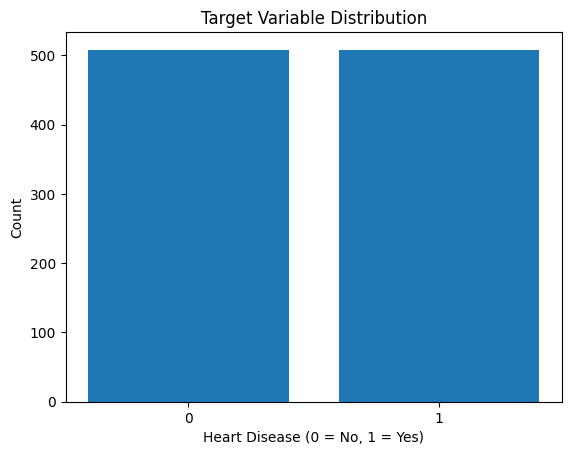

In [13]:
# ============================================
# PLOT 1: TARGET DISTRIBUTION
# ============================================

import matplotlib.pyplot as plt

plt.figure()
counts = df["HeartDisease"].value_counts().sort_index()
plt.bar(counts.index.astype(str), counts.values)

plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.title("Target Variable Distribution")

plt.show()


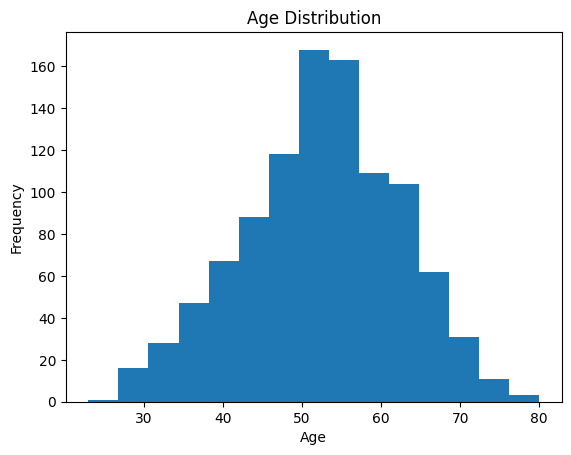

In [14]:
# ============================================
# PLOT 2: AGE DISTRIBUTION
# ============================================

plt.figure()
plt.hist(df["Age"], bins=15)

plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution")

plt.show()


/tmp/ipython-input-3695809612.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([age_no, age_yes],


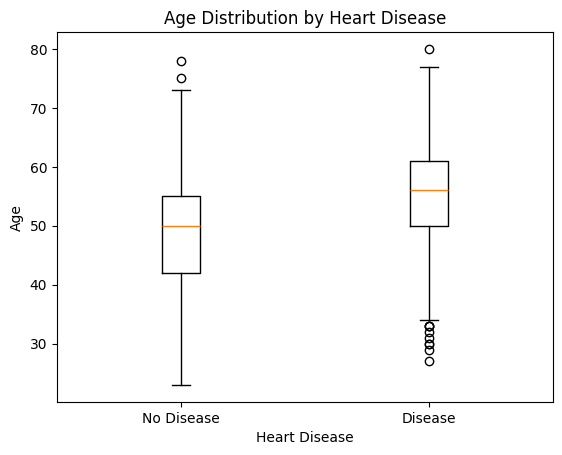

In [15]:
# ============================================
# PLOT 3: AGE vs HEART DISEASE
# ============================================

plt.figure()

age_no = df[df["HeartDisease"] == 0]["Age"]
age_yes = df[df["HeartDisease"] == 1]["Age"]

plt.boxplot([age_no, age_yes],
            labels=["No Disease", "Disease"])

plt.xlabel("Heart Disease")
plt.ylabel("Age")
plt.title("Age Distribution by Heart Disease")

plt.show()


Numeric columns used in correlation:
['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'HeartDisease']


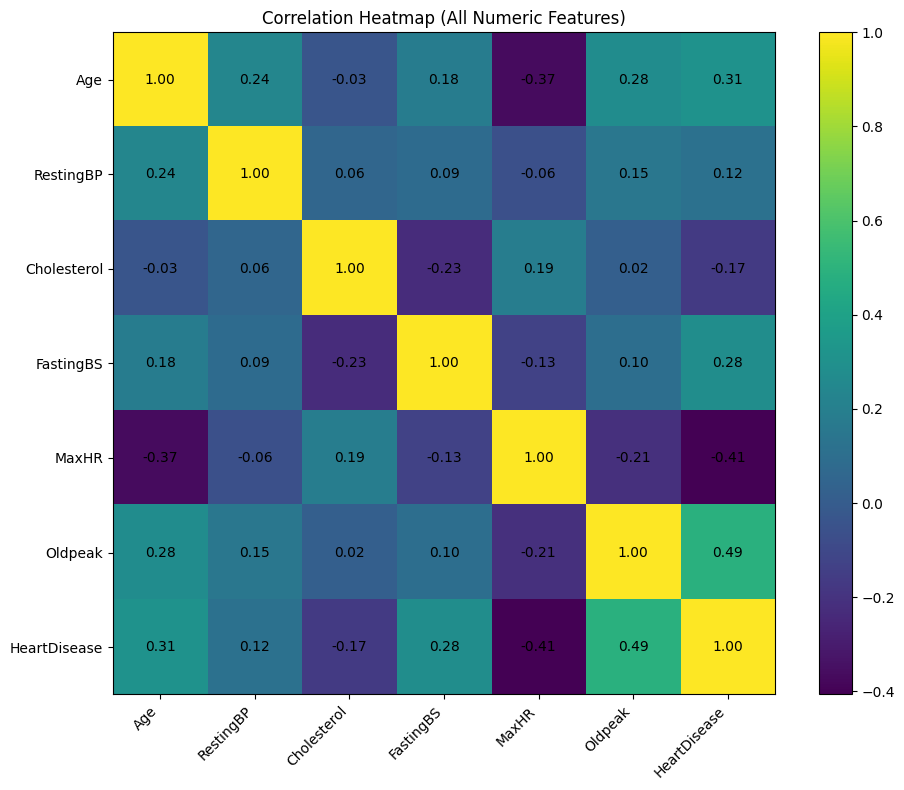

In [18]:
# ============================================
# CORRELATION HEATMAP
# ============================================

import matplotlib.pyplot as plt

# Select only numeric columns
numeric_df = df.select_dtypes(include=["int64", "float64"])

print("Numeric columns used in correlation:")
print(numeric_df.columns.tolist())

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix)
plt.colorbar()

# Axis ticks and labels
plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=45,
    ha="right"
)
plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns
)

# Annotate correlation values
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        plt.text(
            j, i,
            f"{corr_matrix.iloc[i, j]:.2f}",
            ha="center", va="center"
        )

plt.title("Correlation Heatmap (All Numeric Features)")
plt.tight_layout()
plt.show()


<Figure size 640x480 with 0 Axes>

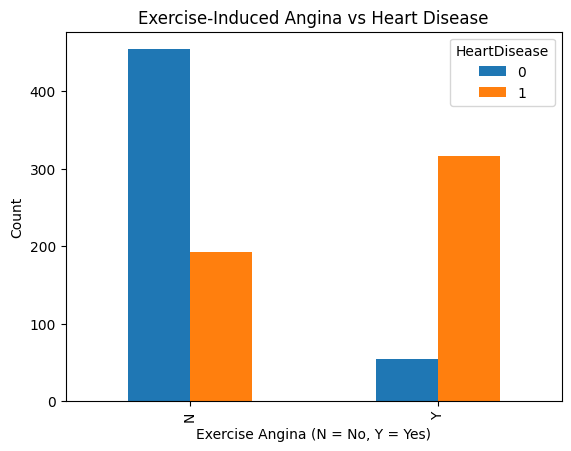

In [17]:
# ============================================
# PLOT 5: EXERCISE ANGINA vs HEART DISEASE
# ============================================

plt.figure()

angina_hd = df.groupby(["ExerciseAngina", "HeartDisease"]).size().unstack()
angina_hd.plot(kind="bar")

plt.xlabel("Exercise Angina (N = No, Y = Yes)")
plt.ylabel("Count")
plt.title("Exercise-Induced Angina vs Heart Disease")
plt.legend(title="HeartDisease")

plt.show()


In [19]:
# ============================================
# CELL 1: FEATURE SELECTION
# ============================================

# Target variable
target = "HeartDisease"

# Separate features and target
X = df.drop(columns=[target])
y = df[target]

print("Shape of X (features):", X.shape)
print("Shape of y (target)  :", y.shape)

print("\nFeature columns:")
print(X.columns.tolist())


Shape of X (features): (1016, 11)
Shape of y (target)  : (1016,)

Feature columns:
['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope']


In [20]:
# ============================================
# CELL 2: TRAIN–TEST SPLIT
# ============================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))


X_train shape: (812, 11)
X_test shape : (204, 11)
y_train shape: (812,)
y_test shape : (204,)

Training target distribution:
HeartDisease
1    0.5
0    0.5
Name: proportion, dtype: float64

Testing target distribution:
HeartDisease
1    0.5
0    0.5
Name: proportion, dtype: float64


In [21]:
# ============================================
# CELL 3: ONE-HOT ENCODING
# ============================================

# Combine train and test temporarily to ensure same encoding
X_combined = pd.concat([X_train, X_test], axis=0)

# One-hot encode categorical variables
X_combined_encoded = pd.get_dummies(
    X_combined,
    drop_first=True
)

# Split back into train and test
X_train_enc = X_combined_encoded.iloc[:len(X_train)]
X_test_enc = X_combined_encoded.iloc[len(X_train):]

print("Encoded X_train shape:", X_train_enc.shape)
print("Encoded X_test shape :", X_test_enc.shape)


Encoded X_train shape: (812, 15)
Encoded X_test shape : (204, 15)


In [22]:
# ============================================
# CELL 4: STANDARD SCALER
# ============================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit scaler on training data ONLY
X_train_scaled = scaler.fit_transform(X_train_enc)
X_test_scaled = scaler.transform(X_test_enc)

print("Scaling completed.")
print("Scaled X_train shape:", X_train_scaled.shape)
print("Scaled X_test shape :", X_test_scaled.shape)


Scaling completed.
Scaled X_train shape: (812, 15)
Scaled X_test shape : (204, 15)


In [23]:
# ============================================
# CELL 5: FINAL SANITY CHECKS
# ============================================

# Check for missing values
print("Missing values in X_train:", pd.DataFrame(X_train_scaled).isnull().sum().sum())
print("Missing values in X_test :", pd.DataFrame(X_test_scaled).isnull().sum().sum())

# Final confirmation
print("\nFinal dataset ready for modeling ")


Missing values in X_train: 0
Missing values in X_test : 0

Final dataset ready for modeling 


In [24]:
# ============================================
# MODEL 1: DECISION TREE CLASSIFIER
# ============================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize Decision Tree
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5        # limit depth to reduce overfitting
)

# Train model
dt_model.fit(X_train_scaled, y_train)

# Predict on test data
y_pred_dt = dt_model.predict(X_test_scaled)

# Evaluation
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nDecision Tree Classification Report:\n",
      classification_report(y_test, y_pred_dt))
print("Decision Tree Confusion Matrix:\n",
      confusion_matrix(y_test, y_pred_dt))


Decision Tree Accuracy: 0.8529411764705882

Decision Tree Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.86      0.85       102
           1       0.86      0.84      0.85       102

    accuracy                           0.85       204
   macro avg       0.85      0.85      0.85       204
weighted avg       0.85      0.85      0.85       204

Decision Tree Confusion Matrix:
 [[88 14]
 [16 86]]


In [25]:
# ============================================
# MODEL 2: XGBOOST CLASSIFIER
# ============================================

from xgboost import XGBClassifier

# Initialize XGBoost model
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    random_state=42,
    eval_metric="logloss"
)

# Train model
xgb_model.fit(X_train_scaled, y_train)

# Predict on test data
y_pred_xgb = xgb_model.predict(X_test_scaled)

# Evaluation
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nXGBoost Classification Report:\n",
      classification_report(y_test, y_pred_xgb))
print("XGBoost Confusion Matrix:\n",
      confusion_matrix(y_test, y_pred_xgb))


XGBoost Accuracy: 0.9019607843137255

XGBoost Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.91      0.90       102
           1       0.91      0.89      0.90       102

    accuracy                           0.90       204
   macro avg       0.90      0.90      0.90       204
weighted avg       0.90      0.90      0.90       204

XGBoost Confusion Matrix:
 [[93  9]
 [11 91]]


In [26]:
# ============================================
# MODEL 3: SUPPORT VECTOR MACHINE (SVM)
# ============================================

from sklearn.svm import SVC

# Initialize SVM model
svm_model = SVC(
    kernel="rbf",      # non-linear decision boundary
    C=1.0,
    gamma="scale",
    probability=True,  # needed for ROC curve later
    random_state=42
)

# Train model
svm_model.fit(X_train_scaled, y_train)

# Predict on test data
y_pred_svm = svm_model.predict(X_test_scaled)

# Evaluation
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nSVM Classification Report:\n",
      classification_report(y_test, y_pred_svm))
print("SVM Confusion Matrix:\n",
      confusion_matrix(y_test, y_pred_svm))


SVM Accuracy: 0.8823529411764706

SVM Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.90      0.88       102
           1       0.90      0.86      0.88       102

    accuracy                           0.88       204
   macro avg       0.88      0.88      0.88       204
weighted avg       0.88      0.88      0.88       204

SVM Confusion Matrix:
 [[92 10]
 [14 88]]


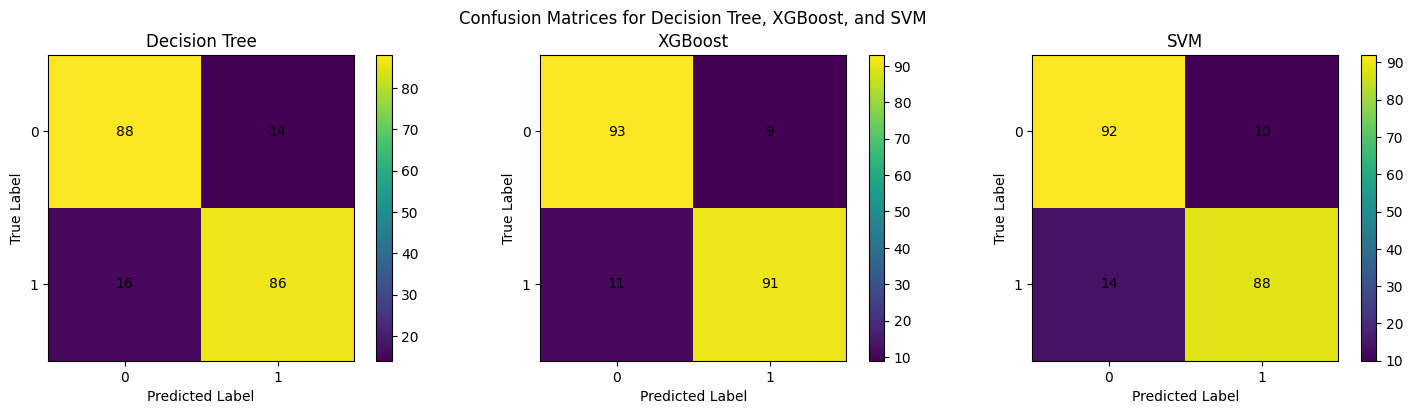

In [27]:
# ============================================
# CONFUSION MATRIX PLOTS
# ============================================

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

models = {
    "Decision Tree": dt_model,
    "XGBoost": xgb_model,
    "SVM": svm_model
}

plt.figure(figsize=(15, 4))

for i, (name, model) in enumerate(models.items(), 1):

    # Predict labels
    y_pred = model.predict(X_test_scaled)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Plot
    plt.subplot(1, 3, i)
    plt.imshow(cm)
    plt.title(name)
    plt.colorbar()

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    plt.xticks([0, 1], ["0", "1"])
    plt.yticks([0, 1], ["0", "1"])

    # Annotate cells
    for r in range(2):
        for c in range(2):
            plt.text(c, r, cm[r, c],
                     ha="center", va="center")

plt.suptitle("Confusion Matrices for Decision Tree, XGBoost, and SVM")
plt.tight_layout()
plt.show()


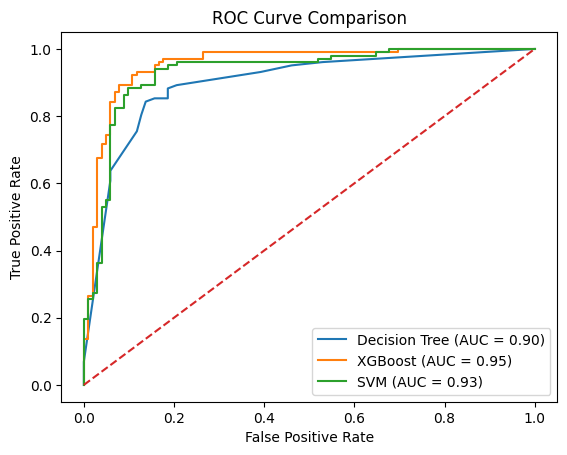

In [28]:
# ============================================
# ROC CURVE COMPARISON
# ============================================

from sklearn.metrics import roc_curve, auc

plt.figure()

for name, model in models.items():

    # Probability for positive class
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    # ROC calculation
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

# Reference line
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


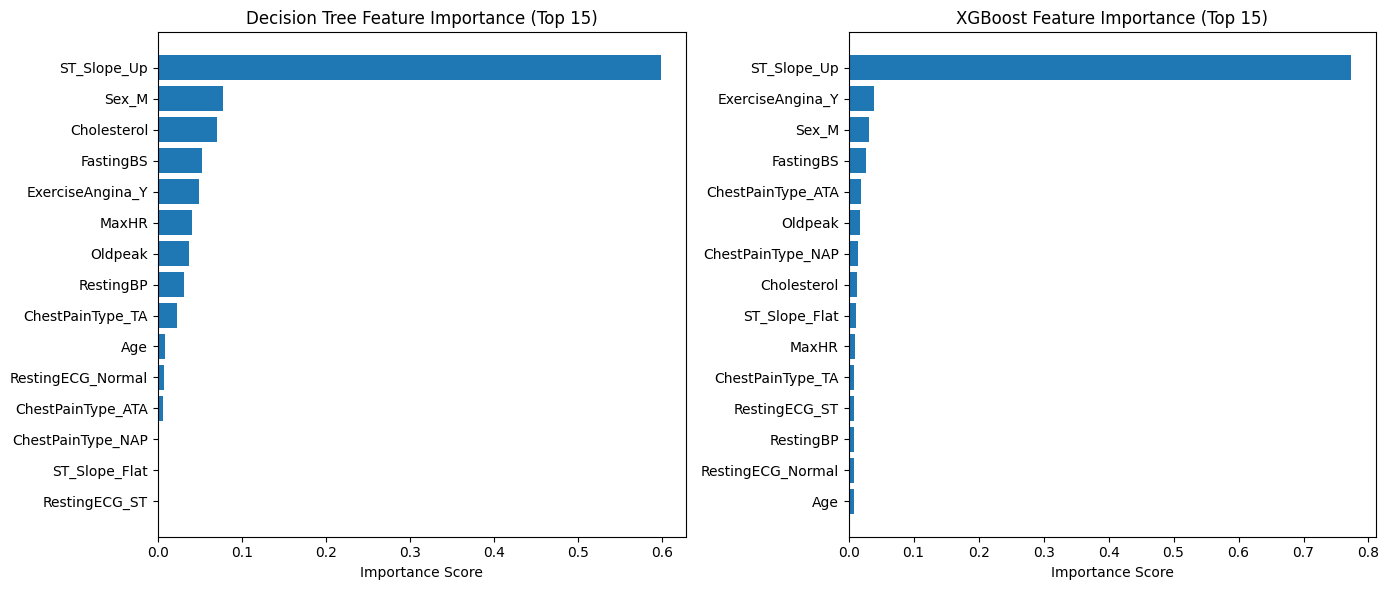

In [29]:
# ============================================
# FEATURE IMPORTANCE (ONE CELL)
# Decision Tree + XGBoost
# ============================================

import numpy as np
import matplotlib.pyplot as plt

# Feature names after encoding
feature_names = X_train_enc.columns.tolist()

# -----------------------------
# Decision Tree importance
# -----------------------------
dt_importance = dt_model.feature_importances_
dt_idx = np.argsort(dt_importance)[::-1][:15]   # top 15 features

# -----------------------------
# XGBoost importance
# -----------------------------
xgb_importance = xgb_model.feature_importances_
xgb_idx = np.argsort(xgb_importance)[::-1][:15] # top 15 features

# -----------------------------
# Plot side-by-side
# -----------------------------
plt.figure(figsize=(14, 6))

# Decision Tree plot
plt.subplot(1, 2, 1)
plt.barh(
    [feature_names[i] for i in dt_idx][::-1],
    dt_importance[dt_idx][::-1]
)
plt.xlabel("Importance Score")
plt.title("Decision Tree Feature Importance (Top 15)")

# XGBoost plot
plt.subplot(1, 2, 2)
plt.barh(
    [feature_names[i] for i in xgb_idx][::-1],
    xgb_importance[xgb_idx][::-1]
)
plt.xlabel("Importance Score")
plt.title("XGBoost Feature Importance (Top 15)")

plt.tight_layout()
plt.show()


In [30]:
# ============================================
# CELL 1: DECISION TREE HYPERPARAMETER TUNING
# ============================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV

dt_param_dist = {
    "max_depth": [None, 3, 5, 7, 10, 15, 20],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "criterion": ["gini", "entropy", "log_loss"]
}

dt_search = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_distributions=dt_param_dist,
    n_iter=30,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1
)

dt_search.fit(X_train_scaled, y_train)

best_dt = dt_search.best_estimator_

print("Best Decision Tree Parameters:")
print(dt_search.best_params_)
print("Best CV ROC-AUC:", dt_search.best_score_)


Best Decision Tree Parameters:
{'min_samples_split': 20, 'min_samples_leaf': 4, 'max_depth': 7, 'criterion': 'log_loss'}
Best CV ROC-AUC: 0.9162125791353934


In [31]:
# ============================================
# CELL 2: XGBOOST HYPERPARAMETER TUNING
# ============================================

from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

xgb_param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [2, 3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 2, 5, 10],
    "gamma": [0, 0.1, 0.2, 0.5]
}

xgb_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),
    param_distributions=xgb_param_dist,
    n_iter=30,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X_train_scaled, y_train)

best_xgb = xgb_search.best_estimator_

print("Best XGBoost Parameters:")
print(xgb_search.best_params_)
print("Best CV ROC-AUC:", xgb_search.best_score_)


Best XGBoost Parameters:
{'subsample': 1.0, 'n_estimators': 200, 'min_child_weight': 2, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.9}
Best CV ROC-AUC: 0.9571005312247909


In [32]:
# ============================================
# CELL 3: SVM HYPERPARAMETER TUNING
# ============================================

from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

svm_param_dist = {
    "C": np.logspace(-2, 2, 10),
    "gamma": ["scale", "auto"] + list(np.logspace(-3, 0, 6)),
    "kernel": ["rbf", "poly", "sigmoid"]
}

svm_search = RandomizedSearchCV(
    estimator=SVC(probability=True, random_state=42),
    param_distributions=svm_param_dist,
    n_iter=30,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1
)

svm_search.fit(X_train_scaled, y_train)

best_svm = svm_search.best_estimator_

print("Best SVM Parameters:")
print(svm_search.best_params_)
print("Best CV ROC-AUC:", svm_search.best_score_)


Best SVM Parameters:
{'kernel': 'rbf', 'gamma': np.float64(0.25118864315095796), 'C': np.float64(0.5994842503189409)}
Best CV ROC-AUC: 0.9561525793584412


In [33]:
# ============================================
# CELL 4: EVALUATE TUNED MODELS ON TEST SET
# ============================================

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

tuned_models = {
    "Decision Tree (Tuned)": best_dt,
    "XGBoost (Tuned)": best_xgb,
    "SVM (Tuned)": best_svm
}

for name, model in tuned_models.items():

    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    print(f"\n--- {name} ---")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("ROC-AUC :", roc_auc_score(y_test, y_prob))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))



--- Decision Tree (Tuned) ---
Accuracy: 0.8431372549019608
ROC-AUC : 0.9004709727028066
Confusion Matrix:
 [[85 17]
 [15 87]]
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.83      0.84       102
           1       0.84      0.85      0.84       102

    accuracy                           0.84       204
   macro avg       0.84      0.84      0.84       204
weighted avg       0.84      0.84      0.84       204


--- XGBoost (Tuned) ---
Accuracy: 0.9068627450980392
ROC-AUC : 0.9479046520569012
Confusion Matrix:
 [[93  9]
 [10 92]]
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.91      0.91       102
           1       0.91      0.90      0.91       102

    accuracy                           0.91       204
   macro avg       0.91      0.91      0.91       204
weighted avg       0.91      0.91      0.91       204


--- SVM (Tuned) ---
Accuracy: 0.8872549019607843
